# Учимся работе с данными - от загрузки до моделирования

In [ ]:
!pip install kaggle

In [4]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Часть 1. EDA

## 1. Скачайте датасет по ссылке: https://www.kaggle.com/uciml/breast-cancer-wisconsin-data

In [5]:
os.makedirs('./data', exist_ok=True)
!kaggle datasets download -d uciml/breast-cancer-wisconsin-data -p ./data

with zipfile.ZipFile('./data/breast-cancer-wisconsin-data.zip', 'r') as zip_ref:
    zip_ref.extractall('./data')

Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
License(s): CC-BY-NC-SA-4.0




  0%|          | 0.00/48.6k [00:00<?, ?B/s]
100%|██████████| 48.6k/48.6k [00:00<00:00, 1.53MB/s]


## 2. Посмотрите на базовые статистики датасета: средние, медианы и т.д.

In [6]:
df = pd.read_csv('./data/data.csv')
print("Данные успешно загружены!")
print(f"Размер датасета: {df.shape}")
df = df.drop('Unnamed: 32', axis=1)
df.info()


Данные успешно загружены!
Размер датасета: (569, 33)
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null 

In [7]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
df.describe(percentiles=[.1, .25, .5, .75, .9])

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
10%,8.531554e+05,10.260000,14.078000,65.830000,321.600000,0.079654,0.049700,0.013686,0.011158,0.149580,...,11.234000,17.800000,72.178000,384.720000,0.102960,0.093676,0.045652,0.038460,0.226120,0.065792
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
90%,8.814422e+07,19.530000,24.992000,129.100000,1177.400000,0.114820,0.175460,0.203040,0.100420,0.214940,...,23.682000,33.646000,157.740000,1673.000000,0.161480,0.447840,0.571320,0.208940,0.360080,0.106320
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## 3. Постройте гистограммы/распределения признаков, при этом используйте целевую переменную, чтобы сгруппировать и раскрасить гистограммы.

In [9]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [10]:
# Создаем список всех признаков (исключаем id и diagnosis)
feature_columns = [col for col in df.columns if col not in ['id', 'diagnosis']]

# Разделяем по типу признаков (mean, se, worst)
mean_features = [col for col in feature_columns if 'mean' in col and 'worst' not in col]
se_features = [col for col in feature_columns if '_se' in col]
worst_features = [col for col in feature_columns if 'worst' in col]

print(f"Всего признаков: {len(feature_columns)}")
print(f"Mean признаки: {len(mean_features)}")
print(f"SE признаки: {len(se_features)}")
print(f"Worst признаки: {len(worst_features)}")

Всего признаков: 30
Mean признаки: 10
SE признаки: 10
Worst признаки: 10


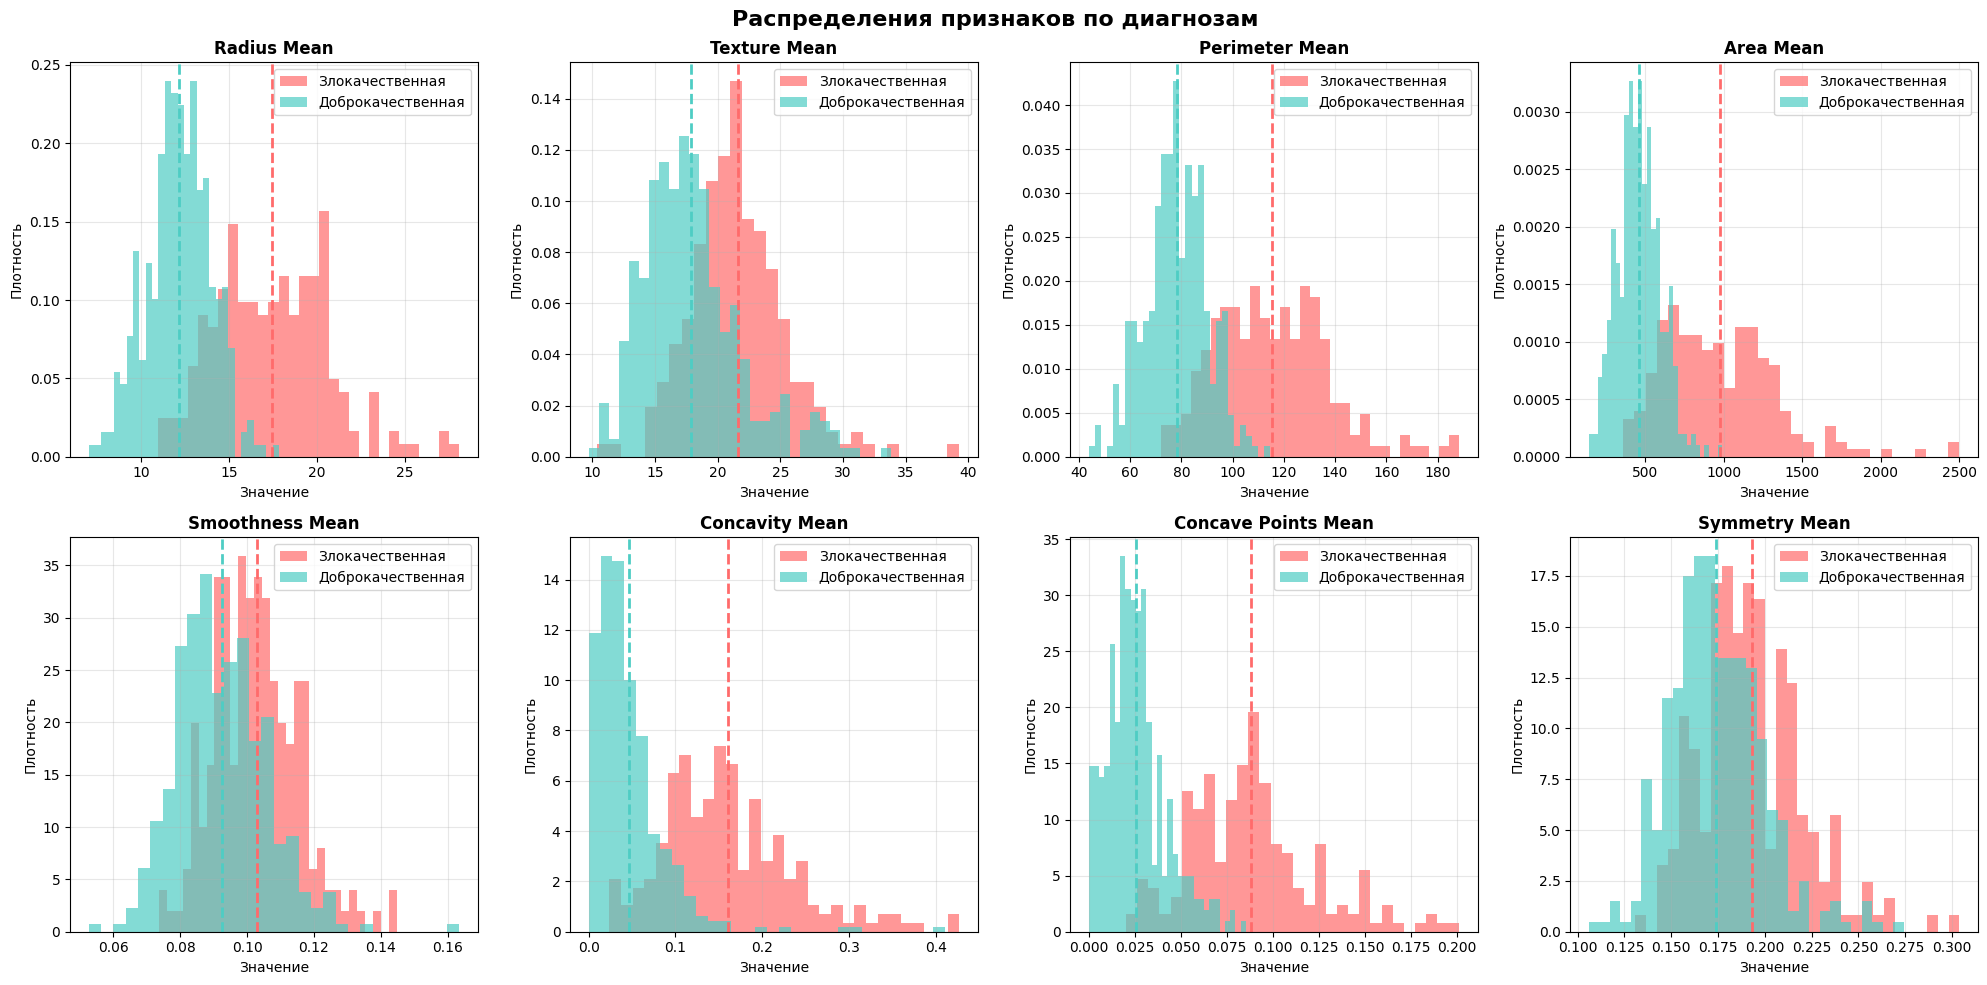

In [11]:
# Настройка цветов: красный для злокачественных (M), зеленый/бирюзовый для доброкачественных (B)
colors = {'M': '#FF6B6B', 'B': '#4ECDC4'}
diagnosis_names = {'M': 'Злокачественная', 'B': 'Доброкачественная'}

# Выбираем несколько ключевых признаков для демонстрации
key_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 
                'smoothness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean']

# Создаем сетку графиков 2x4
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Распределения признаков по диагнозам', fontsize=16, fontweight='bold')

for idx, feature in enumerate(key_features):
    row = idx // 4
    col = idx % 4
    ax = axes[row, col]
    
    # Группируем по диагнозу и строим гистограммы
    for diagnosis, color in colors.items():
        data = df[df['diagnosis'] == diagnosis][feature]
        ax.hist(data, bins=30, alpha=0.7, color=color, 
                label=f'{diagnosis_names[diagnosis]}', density=True)
        
        # Добавляем вертикальные линии средних
        ax.axvline(data.mean(), color=color, linestyle='--', linewidth=2)
    
    # Настройки графика
    feature_name = feature.replace('_', ' ').title()
    ax.set_title(feature_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Значение')
    ax.set_ylabel('Плотность')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Постройте heatmap для матрицы корреляций, есть ли признаки, которые сильно скоррелированы? Какие это признаки? 

In [12]:
# Создаем числовую версию диагноза
df['diagnosis_numeric'] = (df['diagnosis'] == 'M').astype(int)

# Все числовые признаки включая числвой диагноз без колонки id
numeric_df = df.select_dtypes(include=[np.number]).drop('id', axis=1)

print("Размер матрицы корреляций:", numeric_df.shape)
print("Количество признаков:", len(numeric_df.columns))

numeric_df.head()

Размер матрицы корреляций: (569, 31)
Количество признаков: 31


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_numeric
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


Корреляция признаков с диагнозом:
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610


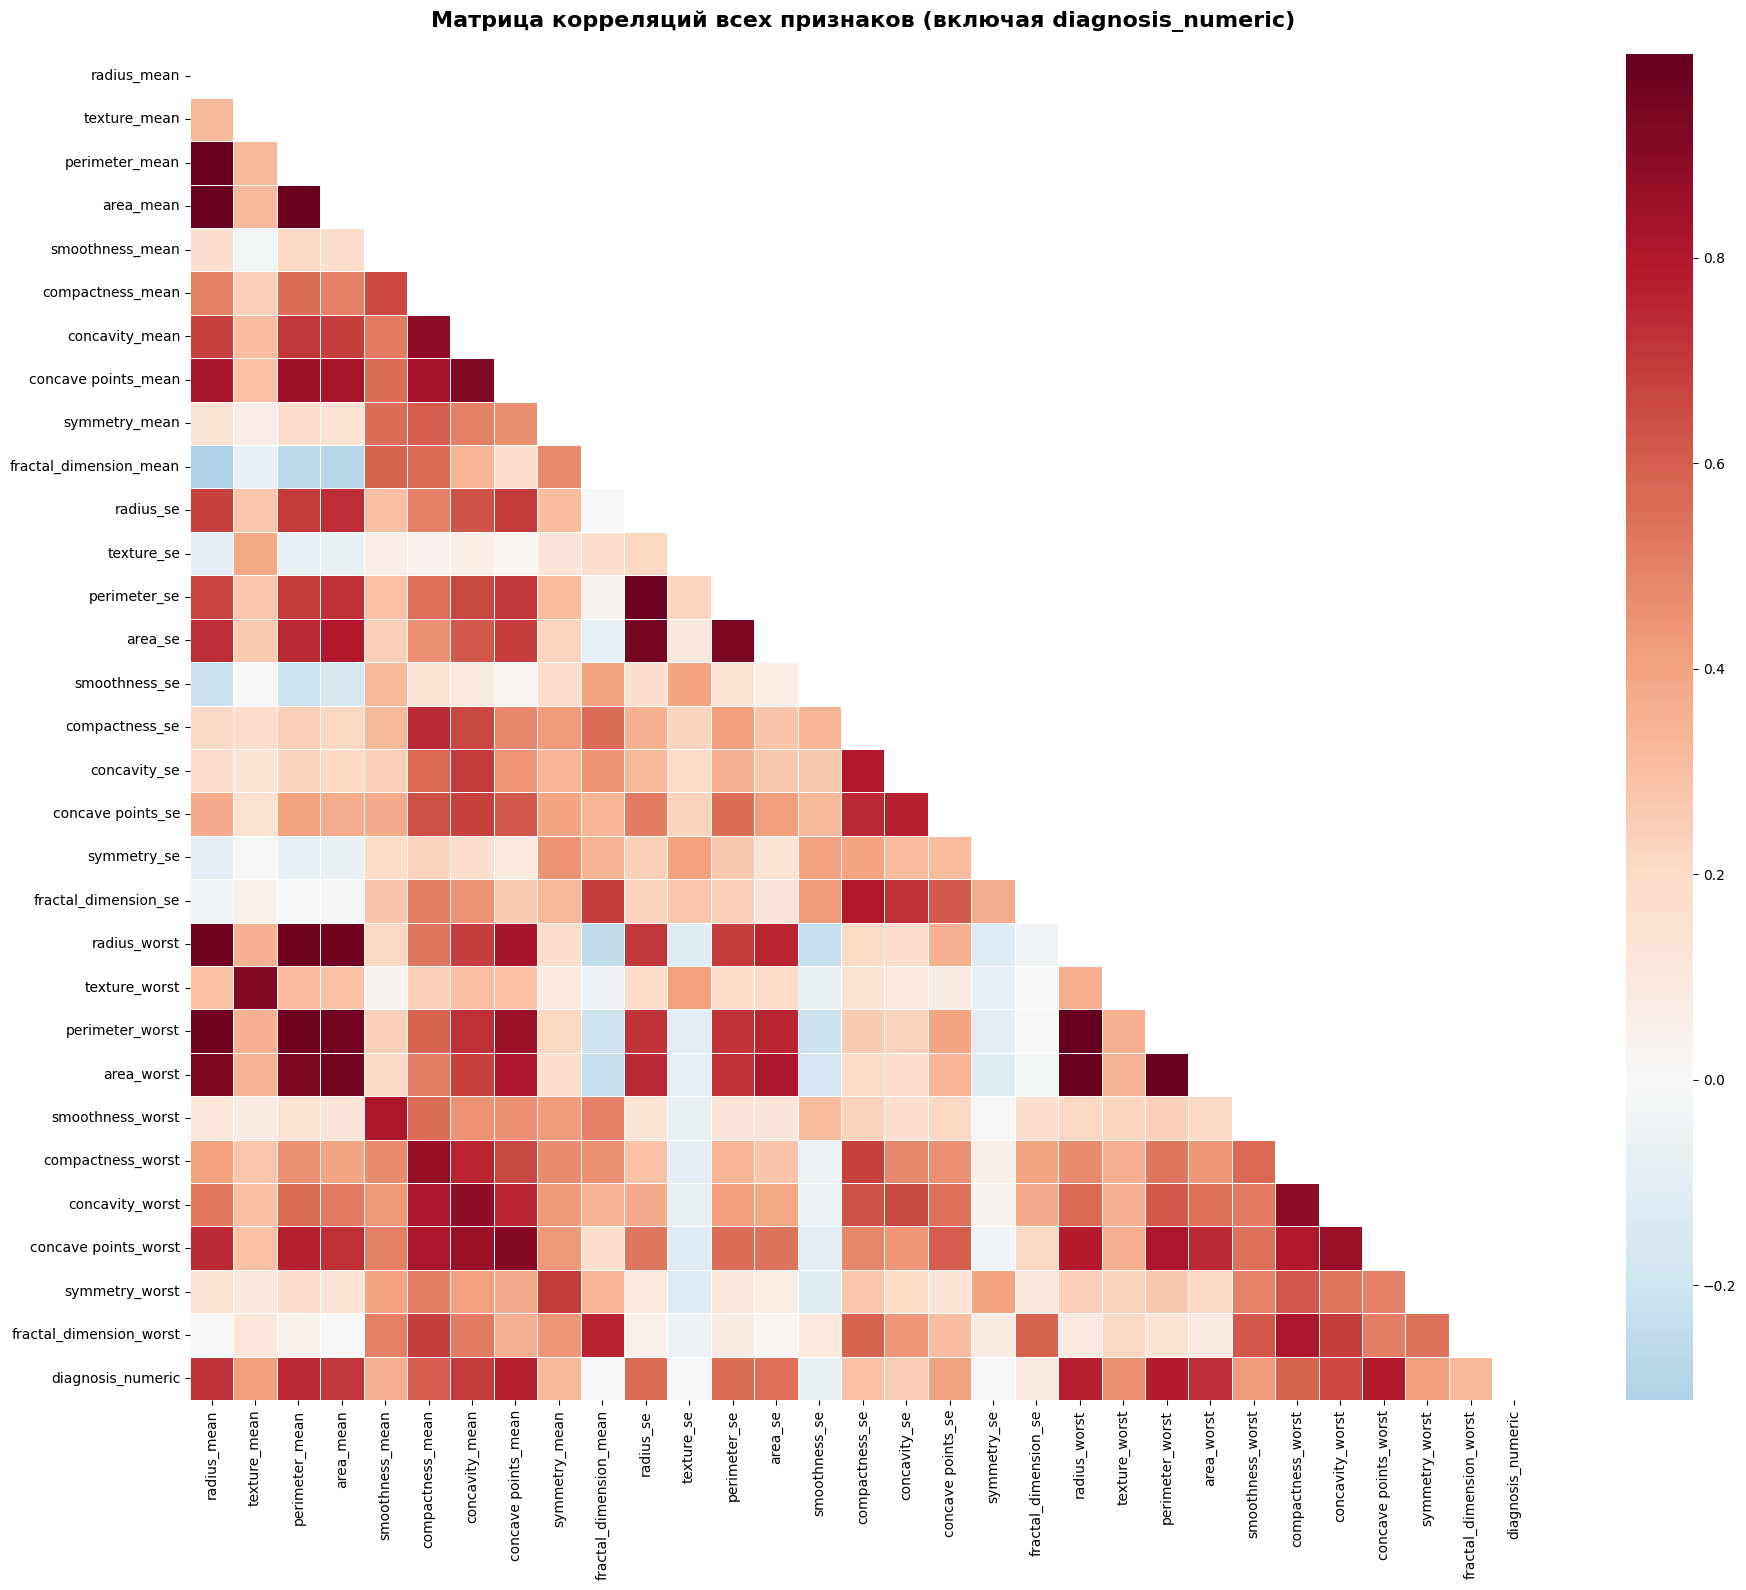

In [13]:
# Вычисляем матрицу корреляций
corr_matrix = numeric_df.corr()

# Анализ корреляций с диагнозом
target_corr = corr_matrix['diagnosis_numeric'].drop('diagnosis_numeric').sort_values(ascending=False)

print("Корреляция признаков с диагнозом:")
print(target_corr.head(10).to_string())

# Создаем маску для верхнего треугольника
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Настраиваем размер графика
plt.figure(figsize=(20, 16))

# Тепловая карта
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=False,  # Без аннотаций для чистоты
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            )

plt.title('Матрица корреляций всех признаков (включая diagnosis_numeric)', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 5. Постройте для сильно скоррелированных признаков попарные scatterplot-ы, действительно ли наблюдается линейная зависимость? 

In [14]:
# Находим сильно скоррелированные пары
threshold = 0.95
high_corr_pairs = []

features_list = [col for col in numeric_df.columns if col != 'diagnosis_numeric']

for i in range(len(features_list)):
    for j in range(i+1, len(features_list)):
        corr_val = corr_matrix.loc[features_list[i], features_list[j]]
        if abs(corr_val) >= threshold:
            high_corr_pairs.append({
                'x1': features_list[i],
                'x2': features_list[j],
                'corr': corr_val,
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
high_corr_df = high_corr_df.sort_values('corr', ascending=False)


print(f"Найдено {len(high_corr_df)} пар с корреляцией >={threshold}")

high_corr_df


Найдено 15 пар с корреляцией >=0.95


,x1,x2,corr
0,radius_mean,perimeter_mean,0.997855
12,radius_worst,perimeter_worst,0.993708
1,radius_mean,area_mean,0.987357
4,perimeter_mean,area_mean,0.986507
13,radius_worst,area_worst,0.984015
14,perimeter_worst,area_worst,0.977578
10,radius_se,perimeter_se,0.972794
6,perimeter_mean,perimeter_worst,0.970387
2,radius_mean,radius_worst,0.969539
5,perimeter_mean,radius_worst,0.969476


In [ ]:
# Счетчики
strictly_linear = 0
close_to_linear = 0
nonlinear = 0

for _, pair in high_corr_df.iterrows():
    x1 = df[pair['x1']]
    x2 = df[pair['x2']]
    
    pearson_r, _ = stats.pearsonr(x1, x2)
    spearman_r, _ = stats.spearmanr(x1, x2)
    diff = abs(pearson_r - spearman_r)
    
    if diff < 0.02:
        strictly_linear += 1
    elif diff < 0.05:
        close_to_linear += 1
    else:
        nonlinear += 1

print(f"Строго линейные: {strictly_linear}")
print(f"Близкие к линейным: {close_to_linear}")
print(f"С заметной нелинейностью: {nonlinear}")
print(f"Всего проанализировано пар: {strictly_linear + close_to_linear + nonlinear}")

Строго линейные: 14
Близкие к линейным: 1
С заметной нелинейностью: 0
Всего проанализировано пар: 15


## 6. Используя boxplots и группировку по целевой переменной, попробуйте предположить, по каким признакам наиболее удобно было бы отделить злокачественные новообразования от доброкачественных.

In [16]:
# Все признаки кроме id и diagnosis
feature_columns = [col for col in df.columns if col not in ['id', 'diagnosis', 'diagnosis_numeric']]

# Простая оценка признаков
feature_ratings = []

for feature in feature_columns:
    data_b = df[df['diagnosis'] == 'B'][feature]
    data_m = df[df['diagnosis'] == 'M'][feature]
    
    # Считаем средние значения для каждого класса
    mean_b = data_b.mean()
    mean_m = data_m.mean()
    
    # Считаем стандартные отклонения
    std_b = data_b.std()
    std_m = data_m.std()
    
    # Простая метрика: насколько средние отличаются относительно разброса
    # Чем больше значение, тем лучше разделение
    separation = abs(mean_m - mean_b) / ((std_b + std_m) / 2)
    
    feature_ratings.append({
        'признак': feature,
        'среднее_B': round(mean_b, 3),
        'среднее_M': round(mean_m, 3),
        'разница_средних': round(abs(mean_m - mean_b), 3),
        'оценка_разделения': round(separation, 2)
    })

# Сортируем по оценке разделения
ratings_df = pd.DataFrame(feature_ratings)
ratings_df = ratings_df.sort_values('оценка_разделения', ascending=False)

ratings_df

,признак,среднее_B,среднее_M,разница_средних,оценка_разделения
27,concave points_worst,0.074,0.182,0.108,2.63
22,perimeter_worst,87.006,141.370,54.364,2.53
7,concave points_mean,0.026,0.088,0.062,2.48
20,radius_worst,13.380,21.135,7.755,2.48
23,area_worst,558.899,1422.286,863.387,2.27
2,perimeter_mean,78.075,115.365,37.290,2.22
0,radius_mean,12.147,17.463,5.316,2.13
3,area_mean,462.790,978.376,515.586,2.05
6,concavity_mean,0.046,0.161,0.115,1.94
26,concavity_worst,0.166,0.451,0.284,1.77


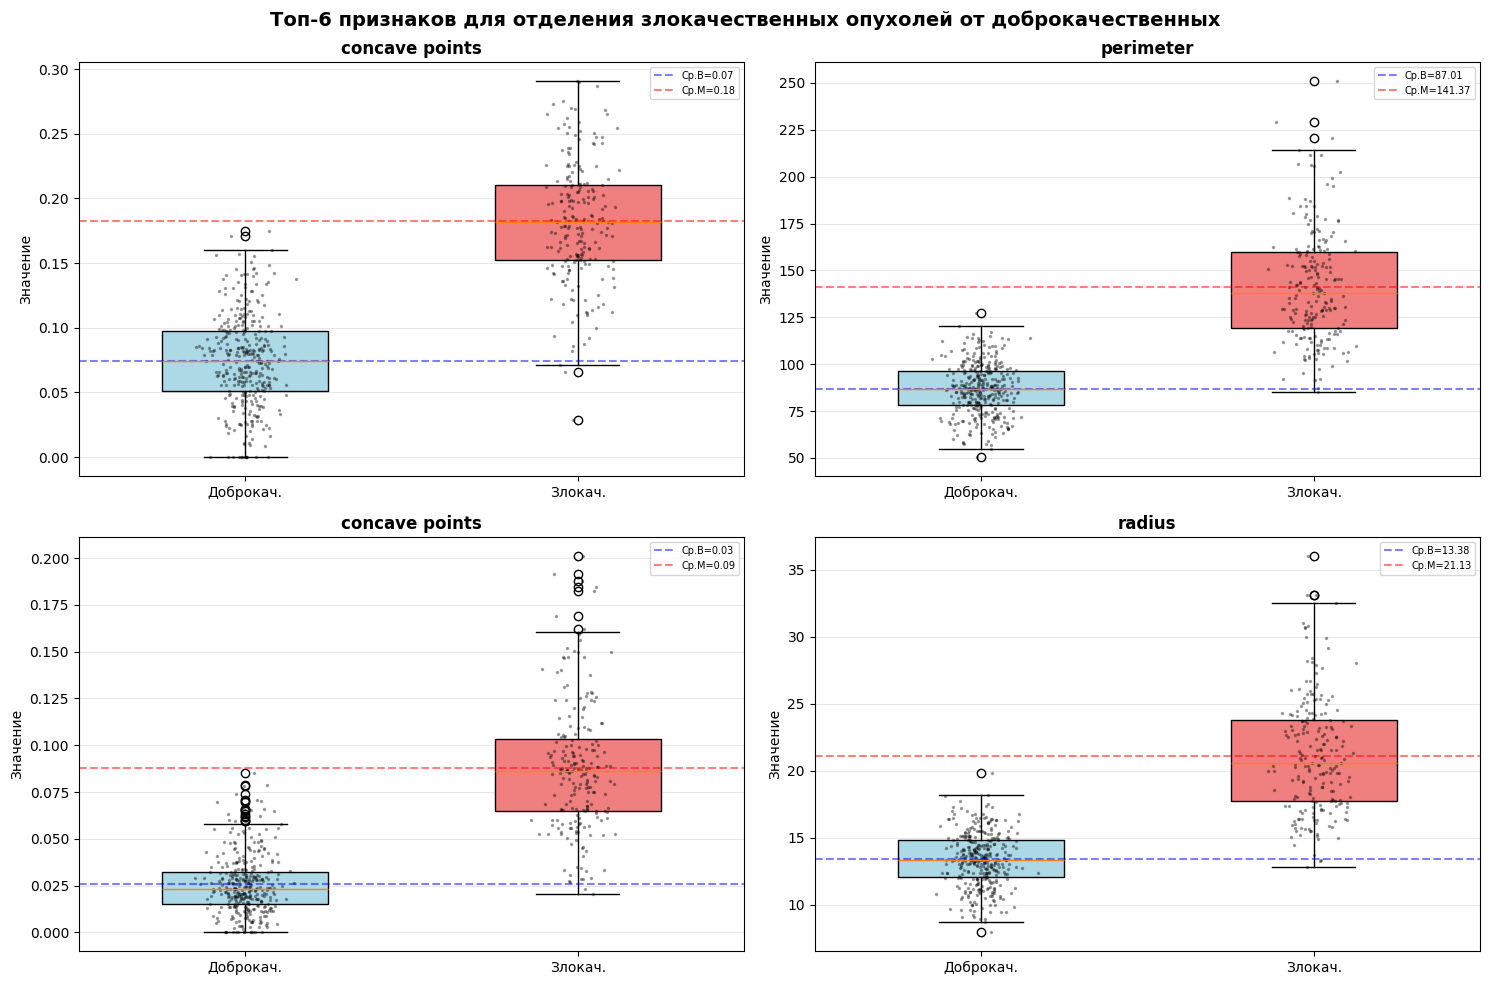

In [17]:
# Берем топ-4 признаков для наглядности
top_simple = ratings_df.head(4)['признак'].tolist()

# Создаем простые boxplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Топ-6 признаков для отделения злокачественных опухолей от доброкачественных', 
             fontsize=14, fontweight='bold')

# Проходим по всем признакам
for i, feature in enumerate(top_simple):
    # Определяем позицию графика
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    # Данные для двух групп
    data_b = df[df['diagnosis'] == 'B'][feature]  # доброкачественные
    data_m = df[df['diagnosis'] == 'M'][feature]  # злокачественные
    
    # Создаем список данных для boxplot
    data_to_plot = [data_b, data_m]
    
    # Рисуем boxplot
    bp = ax.boxplot(data_to_plot, 
                    tick_labels=['Доброкач.', 'Злокач.'],
                    patch_artist=True,
                    widths=0.5)
    
    # Закрашиваем ящики
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    # Добавляем точки данных (чтобы видеть все значения)
    for j, data in enumerate([data_b, data_m], 1):
        # Добавляем небольшой случайный шум по x, чтобы точки не накладывались
        x = np.random.normal(j, 0.05, size=len(data))
        ax.plot(x, data, 'k.', alpha=0.3, markersize=3)
    
    # Добавляем горизонтальную линию на уровне среднего
    ax.axhline(y=data_b.mean(), color='blue', linestyle='--', alpha=0.5, label=f'Ср.B={data_b.mean():.2f}')
    ax.axhline(y=data_m.mean(), color='red', linestyle='--', alpha=0.5, label=f'Ср.M={data_m.mean():.2f}')
    
    # Название признака
    short_name = feature.replace('_', ' ').replace('mean', '').replace('worst', '').strip()
    ax.set_title(f'{short_name}', fontweight='bold')
    ax.set_ylabel('Значение')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Часть 2. Моделирование при помощи kNN

## 1. Разбейте данные на train-test, отложив 30% выборки для тестирования.

In [18]:
from sklearn.model_selection import train_test_split

# Признаки (X) - все колонки кроме id, diagnosis и diagnosis_numeric
X = df.drop(['id', 'diagnosis', 'diagnosis_numeric'], axis=1)

# Целевая переменная (y) - текстовый diagnosis (M/B)
y = df['diagnosis_numeric']

# Разбиваем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y  # сохраняем пропорции классов
)

## 2. Приведите все непрерывные переменные к одному масштабу при помощи стандартизации. Кратко поясните, почему стандартизация здесь нужна.

In [19]:
def show_features_stats(data, title="Статистика признаков"):
    """
    Показывает min, max, среднее и std для нескольких ключевых признаков
    """
    print(f"{title}:")
    print("-" * 60)
    
    # Выбираем несколько признаков с разными масштабами
    key_features = ['radius_mean', 'area_mean', 'smoothness_mean', 
                   'concave points_mean', 'texture_mean']
    
    stats_data = []
    for feature in key_features:
        if feature in data.columns:
            stats_data.append({
                'признак': feature,
                'min': data[feature].min(),
                'max': data[feature].max(),
                'среднее': data[feature].mean(),
                'std': data[feature].std()
            })
    
    stats_df = pd.DataFrame(stats_data)
    # Форматируем вывод в зависимости от масштаба
    for _, row in stats_df.iterrows():
        if 'area' in row['признак']:
            print(f"   {row['признак']:20} min:{row['min']:8.1f}  max:{row['max']:8.1f}  "
                  f"среднее:{row['среднее']:8.1f}  std:{row['std']:7.1f}")
        elif 'smooth' in row['признак'] or 'concave' in row['признак']:
            print(f"   {row['признак']:20} min:{row['min']:8.4f}  max:{row['max']:8.4f}  "
                  f"среднее:{row['среднее']:8.4f}  std:{row['std']:7.4f}")
        else:
            print(f"   {row['признак']:20} min:{row['min']:8.2f}  max:{row['max']:8.2f}  "
                  f"среднее:{row['среднее']:8.2f}  std:{row['std']:7.2f}")
    
    # Показываем разницу в масштабах
    print(f"\n   Диапазоны значений:")
    print(f"      radius_mean: от {data['radius_mean'].min():.2f} до {data['radius_mean'].max():.2f}")
    print(f"      area_mean: от {data['area_mean'].min():.1f} до {data['area_mean'].max():.1f}")
    print(f"      smoothness_mean: от {data['smoothness_mean'].min():.4f} до {data['smoothness_mean'].max():.4f}")

In [20]:
# Показываем статистику до стандартизации
show_features_stats(X_train, "до стандартизации")

до стандартизации:
------------------------------------------------------------
   radius_mean          min:    6.98  max:   28.11  среднее:   14.13  std:   3.55
   area_mean            min:   143.5  max:  2499.0  среднее:   655.3  std:  353.7
   smoothness_mean      min:  0.0625  max:  0.1634  среднее:  0.0959  std: 0.0144
   concave points_mean  min:  0.0000  max:  0.2012  среднее:  0.0485  std: 0.0393
   texture_mean         min:    9.71  max:   39.28  среднее:   19.44  std:   4.32

   Диапазоны значений:
      radius_mean: от 6.98 до 28.11
      area_mean: от 143.5 до 2499.0
      smoothness_mean: от 0.0625 до 0.1634


In [21]:
from sklearn.preprocessing import StandardScaler

# Создаем объект StandardScaler
scaler = StandardScaler()

# Обучаем scaler на ТОЛЬКО обучающей выборке
scaler.fit(X_train)

# Преобразуем обучающую и тестовую выборки
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# После стандартизации преобразуем обратно в DataFrame
X_train_scaled_df = pd.DataFrame(
    scaler.transform(X_train), 
    columns=X_train.columns
)
# Показываем статистику после стандартизации
show_features_stats(X_train_scaled_df, "После стандартизации")


После стандартизации:
------------------------------------------------------------
   radius_mean          min:   -2.01  max:    3.94  среднее:    0.00  std:   1.00
   area_mean            min:    -1.4  max:     5.2  среднее:     0.0  std:    1.0
   smoothness_mean      min: -2.3185  max:  4.6960  среднее: -0.0000  std: 1.0013
   concave points_mean  min: -1.2358  max:  3.8873  среднее: -0.0000  std: 1.0013
   texture_mean         min:   -2.25  max:    4.60  среднее:   -0.00  std:   1.00

   Диапазоны значений:
      radius_mean: от -2.01 до 3.94
      area_mean: от -1.4 до 5.2
      smoothness_mean: от -2.3185 до 4.6960


Стандартизация нужна, чтобы привести все признаки к одному масштабу, иначе признаки с большими числовыми значениями (например, area_mean ~ 1000) будут доминировать над признаками с малыми значениями (например, smoothness_mean ~ 0.1) только из-за разницы в масштабах, а не из-за реальной важности.

## 3. Постройте модель kNN «из коробки» без настройки параметров. Оцените метрики качества бинарной классификации (accuracy, precision, recall, f1_score), постройте ROC-кривую и посчитайте площадь под ней.

In [41]:
from sklearn.neighbors import KNeighborsClassifier

# Создаем модель kNN с параметрами по умолчанию
knn_default = KNeighborsClassifier()

# Обучаем модель
knn_default.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [48]:

y_train_pred = knn_default.predict(X_train_scaled)

# Предсказания классов
y_pred = knn_default.predict(X_test_scaled)
y_pred

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1])

In [59]:
# Вероятности для ROC-кривой
y_pred_proba = knn_default.predict_proba(X_test_scaled)[:,1]
y_pred_proba

array([0.2, 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0.8, 0. , 0. , 1. , 0. ,
       0. , 0. , 0. , 0. , 1. , 1. , 1. , 1. , 0.2, 1. , 0. , 0. , 1. ,
       1. , 1. , 0. , 0. , 0.8, 0. , 0. , 1. , 0. , 0.2, 1. , 0.8, 0. ,
       1. , 1. , 0. , 1. , 0. , 0. , 1. , 0.8, 0. , 0.8, 0. , 0. , 0.6,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 1. , 1. ,
       0.4, 1. , 0. , 0. , 0. , 0. , 0.4, 0. , 0.2, 1. , 0. , 0. , 1. ,
       0. , 0.2, 0. , 0. , 0. , 1. , 0. , 1. , 0. , 0. , 0. , 0. , 0. ,
       0.6, 1. , 1. , 1. , 1. , 0. , 0. , 0. , 0. , 0. , 1. , 1. , 0. ,
       1. , 0. , 1. , 1. , 0. , 1. , 0. , 0.6, 0. , 0. , 1. , 0.2, 0.2,
       1. , 0. , 0. , 1. , 1. , 0. , 0.8, 0. , 0.2, 0. , 0. , 1. , 0.8,
       1. , 0. , 0. , 1. , 0. , 0.8, 0.2, 0. , 0. , 0. , 0. , 1. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 1. , 1. , 0. , 0. , 0. , 0. , 0.4,
       0. , 0. , 1. , 0.2, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.8, 0.2,
       0. , 1. ])

In [60]:
# Сравниваем и проверяем 

def compare_test_pred(y_test, y_pred, n = 10):
    # Сравним первые несколько предсказаний с реальными значениями
    comparison = pd.DataFrame({
        'Реальное значение': y_test.values[:n],
        'Предсказание': y_pred[:n],
        'Совпало?': y_test.values[:n] == y_pred[:n]
    })

    return comparison

comparison = compare_test_pred(y_test, y_pred, 30)

comparison

,Реальное значение,Предсказание,Совпало?
0,0,0,True
1,0,0,True
2,0,0,True
3,0,0,True
4,0,0,True
5,0,0,True
6,1,1,True
7,0,0,True
8,1,1,True
9,0,0,True


In [61]:
# Оценка метрик

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

def quality_report(prediction, actual):
    print("Accuracy: {:.3f}\nPrecision: {:.3f}\nRecall: {:.3f}\nf1_score: {:.3f}".format(
        accuracy_score(prediction, actual),
        precision_score(prediction, actual),
        recall_score(prediction, actual),
        f1_score(prediction, actual)
    ))


print("\nКачество на трене:")
quality_report(y_train_pred, y_train)

print("\nКачество на тесте:")
quality_report(y_pred, y_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)

roc_auc



Качество на трене:
Accuracy: 0.972
Precision: 0.932
Recall: 0.993
f1_score: 0.962

Качество на тесте:
Accuracy: 0.965
Precision: 0.906
Recall: 1.000
f1_score: 0.951


0.9881717289719626


 ROC-AUC на тесте: 0.9881717289719626


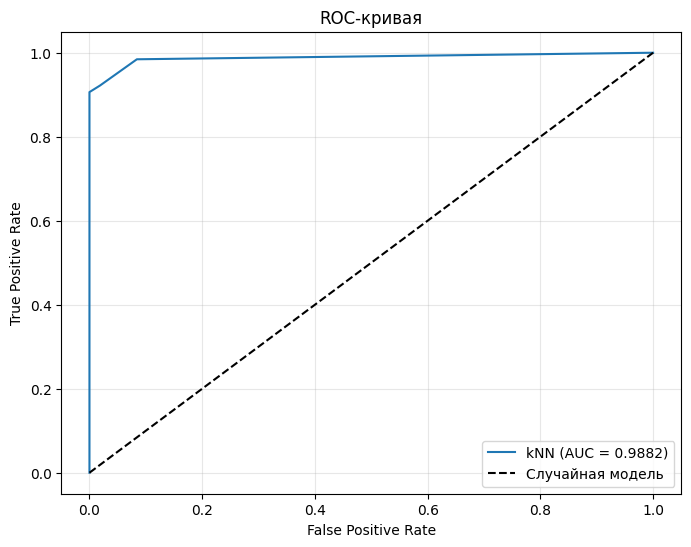

In [68]:
print(f"\n ROC-AUC на тесте: {roc_auc}")

# Строим ROC-кривую
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'kNN (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Создаем кросс-валидацию (5 фолдов)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Перебираем разные значения k (от 1 до 20)
k_values = range(1, 21)
cv_scores = []
cv_scores_std = []

print("Оценка качества для разных k (5-fold CV):")
print("-" * 60)

for k in k_values:
    # Создаем модель с текущим k
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Считаем accuracy на кросс-валидации
    scores = cross_val_score(knn, X_train_scaled, y_train, 
                            cv=cv, scoring='accuracy')
    
    cv_scores.append(scores.mean())
    cv_scores_std.append(scores.std())
    
    print(f"   k = {k:2d}: accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

# Находим лучшее k
best_k = k_values[np.argmax(cv_scores)]
best_score = max(cv_scores)

print(f"Лучшее k = {best_k} с accuracy = {best_score:.4f} на кросс-валидации")

Оценка качества для разных k (5-fold CV):
------------------------------------------------------------
   k =  1: accuracy = 0.9473 (+/- 0.0165)
   k =  2: accuracy = 0.9572 (+/- 0.0130)
   k =  3: accuracy = 0.9572 (+/- 0.0206)
   k =  4: accuracy = 0.9522 (+/- 0.0169)
   k =  5: accuracy = 0.9622 (+/- 0.0241)
   k =  6: accuracy = 0.9547 (+/- 0.0190)
   k =  7: accuracy = 0.9672 (+/- 0.0235)
   k =  8: accuracy = 0.9622 (+/- 0.0266)
   k =  9: accuracy = 0.9697 (+/- 0.0317)
   k = 10: accuracy = 0.9622 (+/- 0.0289)
   k = 11: accuracy = 0.9672 (+/- 0.0296)
   k = 12: accuracy = 0.9597 (+/- 0.0271)
   k = 13: accuracy = 0.9597 (+/- 0.0271)
   k = 14: accuracy = 0.9597 (+/- 0.0247)
   k = 15: accuracy = 0.9571 (+/- 0.0285)
   k = 16: accuracy = 0.9571 (+/- 0.0285)
   k = 17: accuracy = 0.9597 (+/- 0.0271)
   k = 18: accuracy = 0.9571 (+/- 0.0274)
   k = 19: accuracy = 0.9622 (+/- 0.0228)
   k = 20: accuracy = 0.9521 (+/- 0.0283)

✅ Лучшее k = 9 с accuracy = 0.9697 на кросс-валидации
